In [1177]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

# conda clean --all

In [1178]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [1179]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
# Zs = 1 / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix
R0full = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
X0full = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
VincFull = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Urwg = np.loadtxt(r"Urwg_dipole.txt", delimiter=',') # structural modes matrix

# Lmat = np.loadtxt(r"Lmat_patch21ka1.txt", delimiter=',') # lossy matrix
# R0full = np.loadtxt(r"R0_patch21ka1.txt", delimiter=',') # radiated power matrix
# X0full = np.loadtxt(r"X0_patch21ka1.txt", delimiter=',') # reactive power matrix
# VincFull = np.loadtxt(r"V_patch21ka1.txt", delimiter=',') # voltage excitation vector
# Urwg = np.loadtxt(r"Urwg_patch21ka1.txt", delimiter=',') # structural modes matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Z0full = R0full + 1j*X0full
VincFull = E0*VincFull


Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195


In [1180]:
ZtotFull = Zs*Lmat + Z0full
Ifull = np.linalg.solve(ZtotFull, VincFull) # current distribution for full plate
Pfull = 0.5*np.real(Ifull.conj().T @ R0full @ Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")


Pdiags = np.ones((Ndes,2), dtype=complex) # gloal constraints
Pdiags[:,0] = 1j

Plist = [sp.diags(Pdiags[:,i]) for i in range(Pdiags.shape[1])]

Bmat = -0.5*R0full
bVec = np.zeros((Ndes,), dtype=complex)
beta = 0
Umat = -1j*ZtotFull
eVec = -1j*VincFull/2

QCQP = DenseSharedProjQCQP(Bmat, bVec, beta,
                            Umat.conj().T, eVec,
                             Plist, verbose = 1
                                )

t1 = time.time()
lags_init = np.zeros((Pdiags.shape[1],))
lags_init[0] = -1  # re-tuned: this (real-power) block must ramp up for dual feasibility with the corrected Umat/eVec
# New interface for specifying optimization hyperparameters. https://dolphindes.readthedocs.io/en/latest/api/dolphindes.cvxopt.OptimizationHyperparameters.html
opt_params = OptimizationHyperparameters(opttol=1e-12,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=30,                
    penalty_ratio=1e-3,           
    penalty_reduction=0.01,        
    break_iter_period=5,          
    verbose=1)

# Note: 'newton' is usually faster than BFGS, both are prety fast with so few constraints.
result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
print(f"bound: {result[0]:.4e}, time: {time.time()-t1}s, Lagrange multipliers: {QCQP.current_lags}")

Objective for full plate: 1.010821e+01 W
Precomputed 2 A matrices and Fs vectors.
Optimizer initialized with parameters:
opttol: 1e-12
gradConverge: True
min_inner_iter: 10
max_restart: 30
penalty_ratio: 0.001
penalty_reduction: 0.01
break_iter_period: 5
verbose: 1
Starting optimization with x0 = [-1.  0.]
Outer iteration 0, penalty_ratio = 0.001, opt_fx = 12.229409615220952
iter_num: 5, prev_fx: inf, opt_fx: 10.121047852716615, opttol: 1e-12
iter_num: 10, prev_fx: 10.121047852716615, opt_fx: 10.121011744466093, opttol: 1e-12
iter_num: 15, prev_fx: 10.121011744466093, opt_fx: 10.120932760129081, opttol: 1e-12
iter_num: 20, prev_fx: 10.120932760129081, opt_fx: 10.120932760125978, opttol: 1e-12
Outer iteration 1, penalty_ratio = 1e-05, opt_fx = 10.120932760125978
iter_num: 5, prev_fx: 10.120932760129081, opt_fx: 10.120932760125985, opttol: 1e-12
bound: 1.0121e+01, time: 0.058525800704956055s, Lagrange multipliers: [-0.98806811 -0.03777125]


In [1181]:
nModes = 65

Uproj = Urwg[:,0:nModes]

def mat_proj(M,P):
    return(P.conj().T @ M @ P)

def vec_proj(v, P):
    return(P.conj().T @ v)

Lmod = mat_proj(Lmat,Uproj)

# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 2 if np.iscomplexobj(Lmod) and np.any(np.imag(Lmod)) else 1, figsize=(6*(2 if np.iscomplexobj(Lmod) and np.any(np.imag(Lmod)) else 1), 5), squeeze=False)
# axes = axes.flatten()

# im0 = axes[0].imshow(np.real(Lmod), cmap='RdBu_r', vmin=-np.max(np.abs(np.real(Lmod))), vmax=np.max(np.abs(np.real(Lmod))))
# axes[0].set_title('Re(Lmod)')
# axes[0].set_xlabel('Mode index')
# axes[0].set_ylabel('Mode index')
# fig.colorbar(im0, ax=axes[0])

# if len(axes) > 1:
#     im1 = axes[1].imshow(np.imag(Lmod), cmap='RdBu_r', vmin=-np.max(np.abs(np.imag(Lmod))), vmax=np.max(np.abs(np.imag(Lmod))))
#     axes[1].set_title('Im(Lmod)')
#     axes[1].set_xlabel('Mode index')
#     axes[1].set_ylabel('Mode index')
#     fig.colorbar(im1, ax=axes[1])

# plt.tight_layout()
# plt.show()

print(f"diagonal error: {np.linalg.norm(Lmod - np.diag(np.diag(Lmod)))/np.linalg.norm(Lmod)}")

LmodChol = np.linalg.cholesky(Lmod).conj().T
LmodCholInv = np.linalg.inv(LmodChol)
Unorm = Uproj @ LmodCholInv

# import matplotlib.pyplot as plt
# plt.figure(figsize=(8, 5))
# plt.bar(np.arange(Ndes), Unorm[:,0], alpha=0.5)
# plt.xlabel('Design Variable Index')
# plt.ylabel('Material Density')
# plt.title('Modal Material Density')
# plt.grid(True)
# plt.show()

diagonal error: 1.8074849207814012e-13


In [1182]:
R0 = mat_proj(R0full,Unorm)
X0 = mat_proj(X0full,Unorm)
Zmat = Zs * mat_proj(Lmat,Unorm)
Vinc = vec_proj(VincFull,Unorm)

Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix
Rmat = np.real(Zmat) # rezistivity matrix

Vzero = np.zeros((nModes,), dtype=complex) # zero vector

Obj = -0.5 * R0
obj = Vzero/2
obj0 = 0

def evalObj(Ivec):
    return(-np.real(Ivec.conj().T @ Obj @ Ivec) + 2*np.real(Ivec.conj().T @ obj) + obj0)

# full plate performance
Ifull = np.linalg.solve(np.eye(nModes) + Z0/Zs, Vinc/Zs) # current distribution for full plate
Pfull = evalObj(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Objective for full plate: 1.010408e+01 W


In [1183]:
Bmat = Obj
bVec = obj
beta = obj0
Umat = -1j*Ztot
eVec = -1j*Vinc/2

In [1184]:
Pdiags = np.column_stack([
    1j *np.eye(nModes, dtype=complex), 
    np.eye(nModes, dtype=complex)
])

# Now Pdiags is a NumPy array, so .shape and [:,i] will work perfectly
Plist = [sp.diags(Pdiags[:,i]) for i in range(Pdiags.shape[1])]

QCQP = DenseSharedProjQCQP(Bmat, bVec, beta,
                            Umat.conj().T, eVec,
                             Plist, verbose = 1
                                )


t1 = time.time()
lags_init = np.zeros((Pdiags.shape[1],))
lags_init[:nModes] = -1  # re-tuned: this (real-power) block must ramp up for dual feasibility with the corrected Umat/eVec
# New interface for specifying optimization hyperparameters. https://dolphindes.readthedocs.io/en/latest/api/dolphindes.cvxopt.OptimizationHyperparameters.html
opt_params = OptimizationHyperparameters(opttol=1e-12,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=30,                
    penalty_ratio=1e-3,           
    penalty_reduction=0.01,        
    break_iter_period=5,          
    verbose=1)

# Note: 'newton' is usually faster than BFGS, both are prety fast with so few constraints.
result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
print(f"bound: {result[0]:.4e}, time: {time.time()-t1}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 130 A matrices and Fs vectors.
Optimizer initialized with parameters:
opttol: 1e-12
gradConverge: True
min_inner_iter: 10
max_restart: 30
penalty_ratio: 0.001
penalty_reduction: 0.01
break_iter_period: 5
verbose: 1
Starting optimization with x0 = [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.]
Outer iteration 0, penalty_ratio = 0.001, opt_fx = 12.207009544849324
iter_num: 5, prev_fx: inf, opt_fx: 10.107170337581687, opttol: 1e-12
iter_num: 10, prev_fx: 10.107170337581687, opt_fx: 10.106311371162883, op

In [1185]:
# Now let's check again for PSD of A. We don't expect the constraints to hold or to have strong duality
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimal eigenvalue: {np.min(np.real(eigenvals))}")

minimal eigenvalue: 0.012739130327842692


In [1186]:
# Now I take the solved QCQP and finetune it with BFGS if necessary.
t1 = time.time()
gcd_final_result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = QCQP.current_lags, opt_params = None)
print(f"bound: {gcd_final_result[0]}, time: {time.time()-t1}s")

# Let's check for PSD-ness and constraints again

lags = QCQP.current_lags
Pdiags = QCQP.Proj.Pdiags
totalA = QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"min eigenvalue: {np.min(np.real(eigenvals))}")

Ivec= QCQP.current_xstar

primar_obj = evalObj(Ivec)
print(f"GCD primary objective: {primar_obj}")
print(f"GCD dual bound: {QCQP.current_dual}")

bound: 10.10408203004473, time: 0.0733938217163086s
min eigenvalue: 0.012739130327838797
GCD primary objective: 10.104082029079107
GCD dual bound: 10.10408203004473


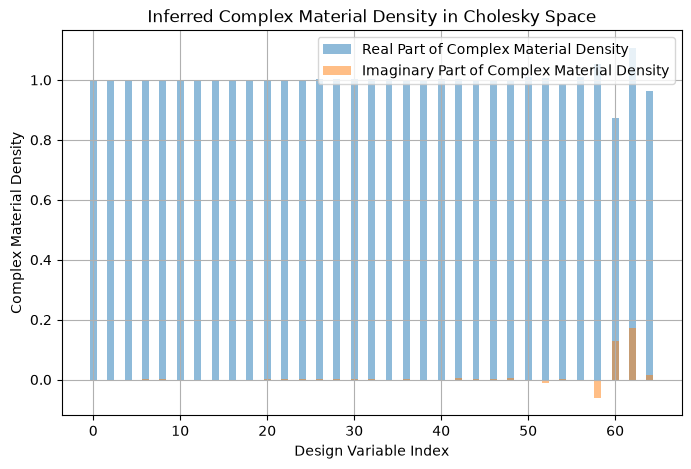

In [1187]:
# Ivec = Ifull

Vopt = Z0 @ Ivec
Vinf = Vinc - Vopt

sigmaInf = Ivec/Vinf
sigmaFull = 1/Zs

complexMaterialDensity = sigmaInf/sigmaFull

sigmaMod = np.diag(complexMaterialDensity/Zs)

# bar plot with real and imaginary parts of Zinf for Ndes design variables
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(nModes), np.real(complexMaterialDensity), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(nModes), np.imag(complexMaterialDensity), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Complex Material Density')
plt.title('Inferred Complex Material Density in Cholesky Space')
plt.legend()
plt.grid(True)
plt.show()


In [1188]:
# complexMaterialDensity = Vzero.copy()
# complexMaterialDensity[1] = 1
# sigmaMod = np.diag(complexMaterialDensity/Zs)

from scipy.optimize import least_squares

# Zmat is currently nModes x nModes (Zs*Lnorm); the fit needs the full Ndes x Ndes
# impedance pattern instead, since d ranges over all Ndes RWG elements.
Zmat_full = Zs * Lmat

# minimize (d_n \in [1e-6,1] for n in 1:Ndes)
#   ||sigmaMod - inv(mat_proj(diag(1/d) @ Zmat_full @ diag(1/d), Unorm))|| / ||sigmaMod||
# diag(1/d) scales up the LOCAL impedance as density drops (Ohm's law: less material
# => higher local resistance), so d=1 means full/undamaged material everywhere;
# the lower bound (not 0) avoids the 1/d singularity at zero density.
def Yfun(d):
    u = 1.0 / d
    M = (u[:, None] * Zmat_full) * u[None, :]  # diag(1/d) @ Zmat_full @ diag(1/d)
    return np.linalg.inv(mat_proj(M, Unorm))

# scipy.optimize.least_squares wants a real residual VECTOR (not a scalar loss), so
# stack the real/imag parts of the flattened complex residual matrix. Normalizing by
# ||sigmaMod|| up front keeps the residual/Jacobian O(1) from the start, same reason
# as the earlier normalization that avoided the d=0 collapse in the minimize version.
sigmaMod_norm = np.linalg.norm(sigmaMod)

def residual_flat(d):
    R = sigmaMod - Yfun(d)
    return np.concatenate([R.real.ravel(), R.imag.ravel()]) / sigmaMod_norm

def jacobian_flat(d):
    # Y = inv(P), P = mat_proj(M(d), Unorm), M(d) = diag(u) @ Zmat_full @ diag(u), u = 1/d.
    # dY/dd_k = -Y @ (dP/dd_k) @ Y  (derivative of a matrix inverse), and
    # dP/dd_k = -u_k^2 * pattern_k, pattern_k = outer(conj(Unorm[k,:]), row_proj[k,:])
    #                                          + outer(col_proj[:,k], Unorm[k,:])
    # (same bilinear structure as the scalar-objective gradient derived earlier), so
    # d(residual)/dd_k = -dY/dd_k = -u_k^2 * (Y @ pattern_k @ Y).
    u = 1.0 / d
    Y = Yfun(d)
    AD = Zmat_full * u[None, :]      # Zmat_full @ diag(u)
    DA = Zmat_full * u[:, None]      # diag(u) @ Zmat_full
    row_proj = AD @ Unorm            # row_proj[k,:] = (Zmat_full @ diag(u))[k,:] @ Unorm
    col_proj = Unorm.conj().T @ DA   # col_proj[:,k] = Unorm^H @ (diag(u) @ Zmat_full)[:,k]
    J = np.empty((2 * nModes * nModes, Ndes))
    for k in range(Ndes):
        pattern = np.outer(Unorm[k, :].conj(), row_proj[k, :]) + np.outer(col_proj[:, k], Unorm[k, :])
        drk = -(u[k] ** 2) * (Y @ pattern @ Y)
        J[:nModes * nModes, k] = drk.real.ravel()
        J[nModes * nModes:, k] = drk.imag.ravel()
    return J / sigmaMod_norm

d0 = np.ones(Ndes)  # start at full density (matches undamaged Zmat_full)
res = least_squares(residual_flat, d0, jac=jacobian_flat, bounds=(1e-3, 1.0),
                     method='trf', xtol=1e-15, ftol=1e-15, gtol=1e-15, max_nfev=5000)
material_density = res.x
rel_err = np.linalg.norm(res.fun)  # residual_flat is already normalized by ||sigmaMod||
print(f"least-squares fit: ||sigmaMod - Y(d)|| / ||sigmaMod|| = {rel_err:.6e} "
      f"(status: {res.status}, {res.nfev} evals)")


least-squares fit: ||sigmaMod - Y(d)|| / ||sigmaMod|| = 6.926526e-01 (status: 2, 25 evals)


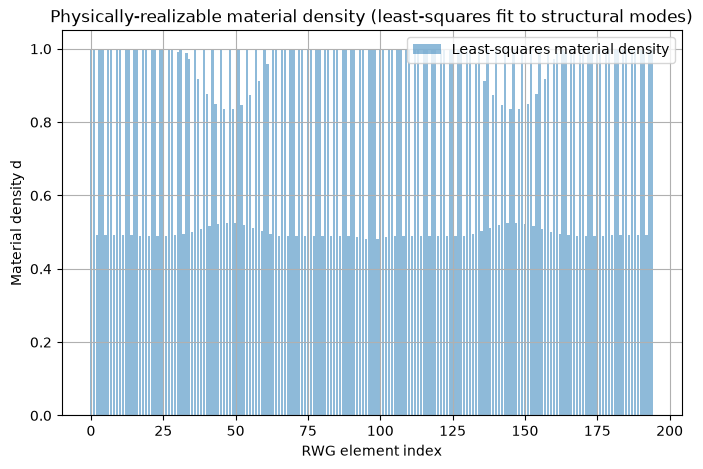

Objective for least-squares fitted material density: 9.9044e+00 W


In [1189]:


plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), material_density, alpha=0.5, label='Least-squares material density')
plt.xlabel('RWG element index')
plt.ylabel('Material density d')
plt.title('Physically-realizable material density (least-squares fit to structural modes)')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate the actual radiated power of this physically-realizable design in the
# full Ndes-dimensional space: local impedance scales as diag(1/d) on both sides,
# matching the fit above.
u_design = 1.0 / material_density
Ztot_full = Z0full + (u_design[:, None] * Zmat_full) * u_design[None, :]
Ifull_design = np.linalg.solve(Ztot_full, VincFull)
Pfull_design = 0.5 * np.real(Ifull_design.conj().T @ R0full @ Ifull_design)
print(f"Objective for least-squares fitted material density: {Pfull_design:.4e} W")

np.savetxt("materialBFdensityPatch21ka1.txt",material_density, delimiter=',')

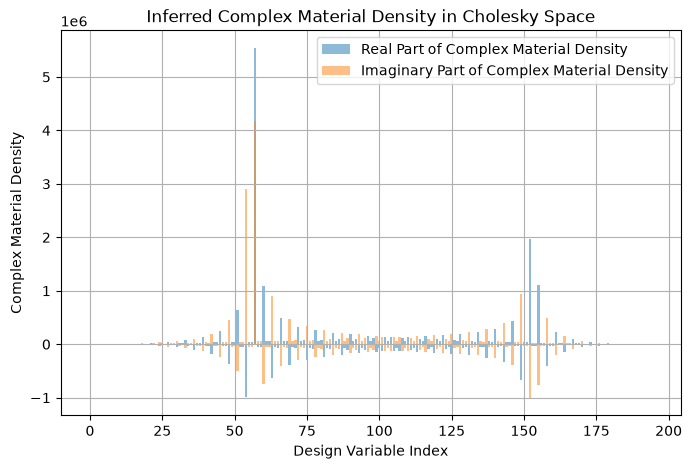

In [1190]:
Irwg = Unorm @ Ivec
Vopt = Z0full @ Irwg
Vinf = VincFull - Vopt

LmatChol = np.linalg.cholesky(Lmat).conj().T

sigmaInf = np.linalg.solve(LmatChol, Irwg)/np.linalg.solve(LmatChol, Vinf)
sigmaFull = 1/Zs

complexMaterialDensity = sigmaInf/sigmaFull

sigmaMod = np.diag(complexMaterialDensity/Zs)

# bar plot with real and imaginary parts of Zinf for Ndes design variables
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensity), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensity), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Complex Material Density')
plt.title('Inferred Complex Material Density in Cholesky Space')
plt.legend()
plt.grid(True)
plt.show()